In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('auto-mpg.csv')
df.head()
df = df.drop([df.columns[0], 'car name'], axis=1)

In [3]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [ ]:
df

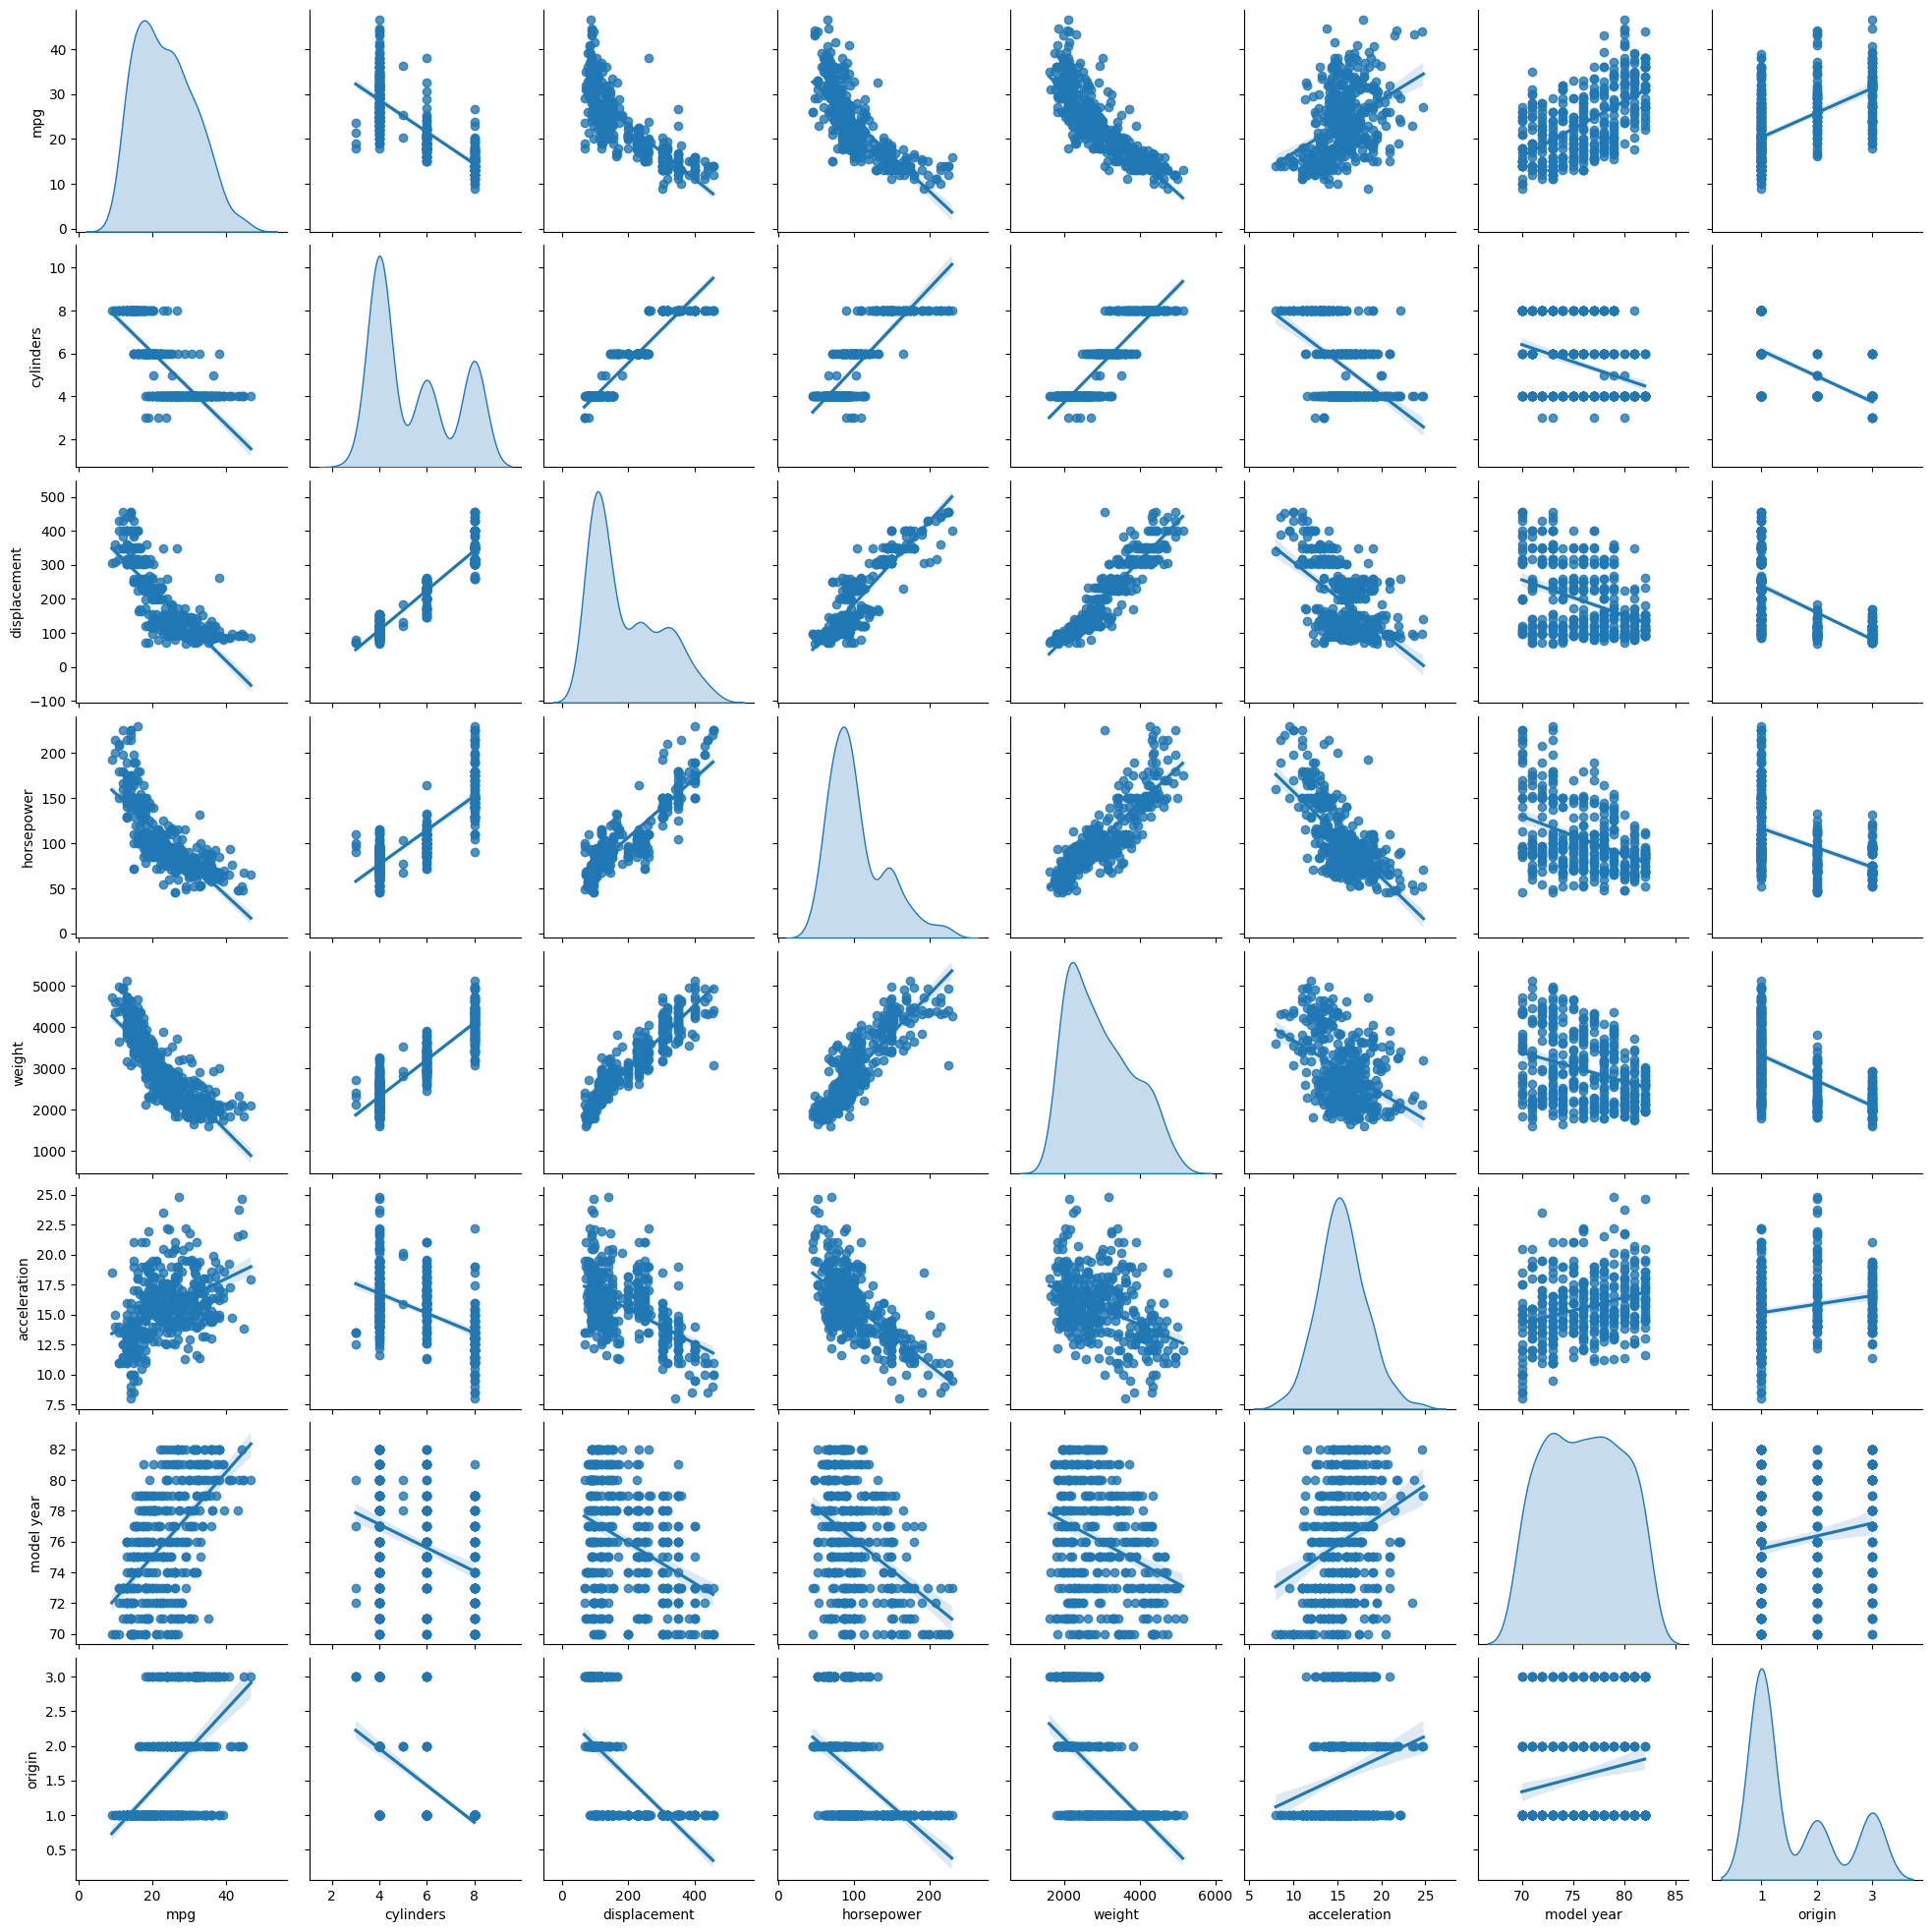

In [4]:
sns.pairplot(df, diag_kind='kde', kind='reg')


<Axes: >

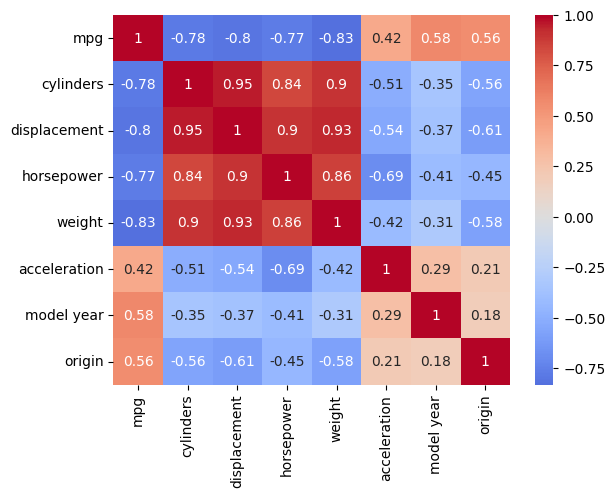

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

In [9]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
dtype: object

In [10]:
df['origin'] = pd.Categorical(df['origin'])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop(('mpg'), axis = 1), df['mpg'], random_state=42, test_size=0.2)

In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sqlalchemy import column

numeric_features = X_train.select_dtypes(['number']).columns.to_list()
categorical_features = X_train.select_dtypes(exclude='number').columns.to_list()

preprocessing = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ]
)

# Step 1: Fit the ColumnTransformer to the training data
preprocessing.fit(X_train)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['cylinders', 'displacement', 'horsepower',
                                  'weight', 'acceleration', 'model year']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['origin'])])

In [13]:
X_train.head()
y_train.head()
train = pd.concat([X_train, y_train], axis = 1)


GLM Results Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                    mpg   No. Observations:                  318
Model:                            GLM   Df Residuals:                      309
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                          17.986
Method:                          IRLS   Log-Likelihood:                -906.10
Date:                Thu, 12 Jun 2025   Deviance:                       5557.6
Time:                        14:17:51   Pearson chi2:                 5.56e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9191
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Interc

Text(0, 0.5, 'Predicted MPG')

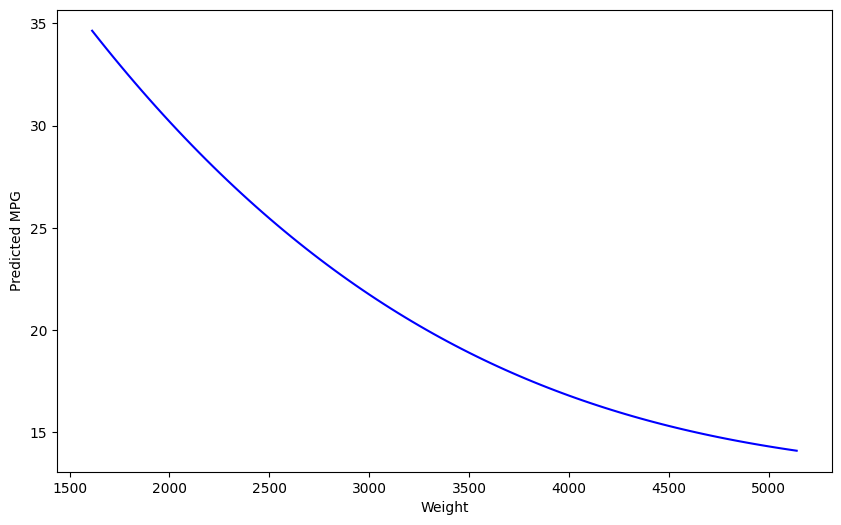

In [14]:
import statsmodels.formula.api as smf

glm = smf.glm(formula = "mpg ~ C(origin) + bs(weight, 3) + acceleration*cylinders", data=train)
glm_results = glm.fit()
print("\nGLM Results Summary:")
print(glm_results.summary())
# Predicting on test set
y_pred = glm_results.predict(X_test)
# Evaluating the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Visualize smooth effect including confidence intervals
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
weight_range = np.linspace(X_train['weight'].min(), X_train['weight'].max(), 100)

weight_smooth = glm_results.predict(pd.DataFrame({
    'weight': weight_range,
    'acceleration': np.mean(X_train['acceleration']),
    'cylinders': np.mean(X_train['cylinders']),
    'origin': 1  # Example for one origin category
}))
plt.plot(weight_range, weight_smooth, label='Smooth Effect of Weight', color='blue')
plt.xlabel('Weight')
plt.ylabel('Predicted MPG')

In [15]:
print(smf.glm(formula = "mpg ~ weight", data=train).fit().summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    mpg   No. Observations:                  318
Model:                            GLM   Df Residuals:                      316
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          19.907
Method:                          IRLS   Log-Likelihood:                -925.80
Date:                Thu, 12 Jun 2025   Deviance:                       6290.7
Time:                        14:17:52   Pearson chi2:                 6.29e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.8842
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.7821      0.920     50.862      0.0

In [16]:
glm_regularized = smf.glm(formula="mpg ~ weight + acceleration + cylinders + C(origin)",
                         data=train).fit_regularized(alpha=0.01, L1_wt=1)

# Extract most important features
important_features = glm_regularized.params.abs().sort_values(ascending=False).head(3)
print("\nMost Important Features:")
print(important_features)


Most Important Features:
Intercept         30.307891
C(origin)[T.3]     3.179986
C(origin)[T.2]     1.633302
dtype: float64


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns

# 1. Load and Prepare the Dataset
# Using seaborn to load the classic mpg dataset
mpg = sns.load_dataset('mpg')

# Drop rows with missing values (horsepower has a few)
mpg = mpg.dropna()

# 'origin' is categorical, but coded as numbers. Convert it to string for clarity.
# In newer versions of seaborn, origin is already an object/string.
mpg['origin'] = mpg['origin'].replace({1: 'USA', 2: 'Europe', 3: 'Japan'})

# 2. Define Features (X) and Target (y)
X = mpg.drop(['mpg', 'name'], axis=1) # Drop target and identifier
y = mpg['mpg']

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# 3. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Create a Preprocessing Pipeline for Feature Standardization and Encoding
# This pipeline ensures that the same transformations are applied consistently
# and avoids data leakage from the test set.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any (none in this case)
)

# 5. Apply Preprocessing
# Fit the preprocessor on the training data and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation for interpreting coefficients
# This is slightly complex because of the one-hot encoding
feature_names = numerical_features + \
                preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()

# statsmodels requires an explicit intercept
X_train_processed = sm.add_constant(X_train_processed, has_constant='add')
X_test_processed = sm.add_constant(X_test_processed, has_constant='add')

# Convert processed arrays back to pandas DataFrames for clarity
X_train_df = pd.DataFrame(X_train_processed, columns=['const'] + feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=['const'] + feature_names, index=X_test.index)


# 6. Define and Train the GLM Models
# We use a Gamma family with a Log link, which is common for strictly positive, skewed data like MPG.
gamma_family = sm.families.Gamma(link=sm.families.links.Log())

# --- Base GLM (No Regularization) ---
base_glm = sm.GLM(y_train, X_train_df, family=gamma_family)
base_results = base_glm.fit()

# --- L1 Regularized GLM (Lasso) ---
# The `fit_regularized` method with L1_wt=1.0 performs L1 regularization.
# alpha is the penalty strength. We choose a value, but in practice, this is often tuned.
l1_glm = sm.GLM(y_train, X_train_df, family=gamma_family)
l1_results = l1_glm.fit_regularized(method='elastic_net', alpha=0.03, L1_wt=1.0, maxiter = 5000)

# --- L2 Regularized GLM (Ridge) ---
# Setting L1_wt=0.0 in the elastic_net method performs L2 regularization.
l2_glm = sm.GLM(y_train, X_train_df, family=gamma_family)
l2_results = l2_glm.fit_regularized(method='elastic_net', alpha=0.1, L1_wt=0.0, maxiter = 50000)


# 7. Evaluate Models and Compare
# --- Predictions ---
y_pred_base = base_results.predict(X_test_df)
y_pred_l1 = l1_results.predict(X_test_df)
y_pred_l2 = l2_results.predict(X_test_df)

# --- Calculate Root Mean Squared Error (RMSE) ---
rmse_base = np.sqrt(np.mean((y_test - y_pred_base)**2))
rmse_l1 = np.sqrt(np.mean((y_test - y_pred_l1)**2))
rmse_l2 = np.sqrt(np.mean((y_test - y_pred_l2)**2))

# --- Compare Coefficients ---
# Create a DataFrame to easily compare the coefficients from each model
coefficients_df = pd.DataFrame({
    'Feature': ['const'] + feature_names,
    'Base_GLM': base_results.params.values,
    'L1_Lasso': l1_results.params.values,
    'L2_Ridge': l2_results.params.values
}).set_index('Feature')


# 8. Print Results
print("### Model Performance (RMSE on Test Set) ###")
print(f"Base GLM: {rmse_base:.4f}")
print(f"L1 Regularized (Lasso): {rmse_l1:.4f}")
print(f"L2 Regularized (Ridge): {rmse_l2:.4f}")
print("\n" + "="*50 + "\n")
print("### Model Coefficients Comparison ###")
print(coefficients_df.round(4))

### Model Performance (RMSE on Test Set) ###
Base GLM: 2.7478
L1 Regularized (Lasso): 2.8112
L2 Regularized (Ridge): 2.7142


### Model Coefficients Comparison ###
               Base_GLM  L1_Lasso  L2_Ridge
Feature                                    
const            2.3570    3.0819    2.3522
cylinders       -0.0422    0.0000   -0.0395
displacement     0.0753   -0.0159    0.0648
horsepower      -0.0586   -0.0294   -0.0568
weight          -0.2173   -0.2021   -0.2141
acceleration    -0.0041    0.0000   -0.0044
model_year       0.1174    0.0912    0.1166
origin_europe    0.8236    0.0000    0.8177
origin_japan     0.8168    0.0000    0.8130
origin_usa       0.7166    0.0000    0.7216


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1492: UserWarning: GLM ridge optimization may have failed, |grad|=0.011183
  warnings.warn(msg)


In [18]:
mpg = pd.read_csv('auto-mpg.csv')
mpg['horsepower'] = pd.to_numeric(mpg['horsepower'], errors='coerce')
mpg['horsepower'] = mpg['horsepower'].fillna(mpg['horsepower'].median())

# 'origin' is categorical, but coded as numbers. Convert it to string for clarity.
# In newer versions of seaborn, origin is already an object/string.
mpg['origin'] = mpg['origin'].replace({1: 'USA', 2: 'Europe', 3: 'Japan'})

# 2. Define Features (X) and Target (y)
X = mpg.drop([mpg.columns[0],'mpg', 'car name'], axis=1) # Drop target and identifier
X = X.rename(columns={'model year': 'model_year'})
y = mpg['mpg']

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# 3. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Create a Preprocessing Pipeline for Feature Standardization and Encoding
# This pipeline ensures that the same transformations are applied consistently
# and avoids data leakage from the test set.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop=f"first", handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any (none in this case)
)

# 5. Apply Preprocessing
# Fit the preprocessor on the training data and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation for interpreting coefficients
# This is slightly complex because of the one-hot encoding
feature_names = numerical_features + \
                preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()

# statsmodels requires an explicit intercept
X_train_processed = sm.add_constant(X_train_processed, has_constant='add')
X_test_processed = sm.add_constant(X_test_processed, has_constant='add')

# Convert processed arrays back to pandas DataFrames for clarity
X_train = pd.DataFrame(X_train_processed, columns=['const'] + feature_names, index=X_train.index)
X_test = pd.DataFrame(X_test_processed, columns=['const'] + feature_names, index=X_test.index)


In [19]:
X_train.head()

,const,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_Japan,origin_USA
3,1.0,1.527188,1.090196,1.265821,0.552826,-1.319334,-1.696667,0.0,1.0
18,1.0,-0.850515,-0.922996,-0.408635,-0.999667,-0.413182,-1.696667,1.0,0.0
376,1.0,-0.850515,-0.981350,-0.948782,-1.124772,0.927922,1.638975,1.0,0.0
248,1.0,-0.850515,-0.981350,-1.164840,-1.392854,0.275493,0.527094,1.0,0.0
177,1.0,-0.850515,-0.747936,-0.219583,-0.327675,-0.231952,-0.306816,0.0,0.0


In [20]:
ols = sm.OLS(y_train, X_train).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     174.6
Date:                Thu, 12 Jun 2025   Prob (F-statistic):          7.96e-110
Time:                        14:17:52   Log-Likelihood:                -837.54
No. Observations:                 318   AIC:                             1693.
Df Residuals:                     309   BIC:                             1727.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           25.4817      0.517     49.262      0.000      24.464      26.500
cylinders       -0.2787      0.637     -0.438      0.662      -1.531       0.974
displacement     2.0334      0.915      2.221      0.027       0.232       3.835
horsepower      -0.5392      0.577     -0.934      0.351      -1.675       0.597
weight          -5.9147      0.621     -9.524      0.000      -7.137      -4.693
acceleration     0.1875      0.303      0.619      0.536      -0.408       0.783
model_year       2.9714      0.220     13.519      0.000       2.539       3.404
origin_Japan    -0.2758      0.640     -0.431      0.667      -1.534       0.983
origin_USA      -2.9469      0.647     -4.553      0.000      -4.220      -1.673
==============================================================================
Omnibus:                       16.138   Durbin-Watson:                   2.172
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.853
Skew:                           0.417   Prob(JB):                     2.96e-05
Kurtosis:                       3.937   Cond. No.                         12.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

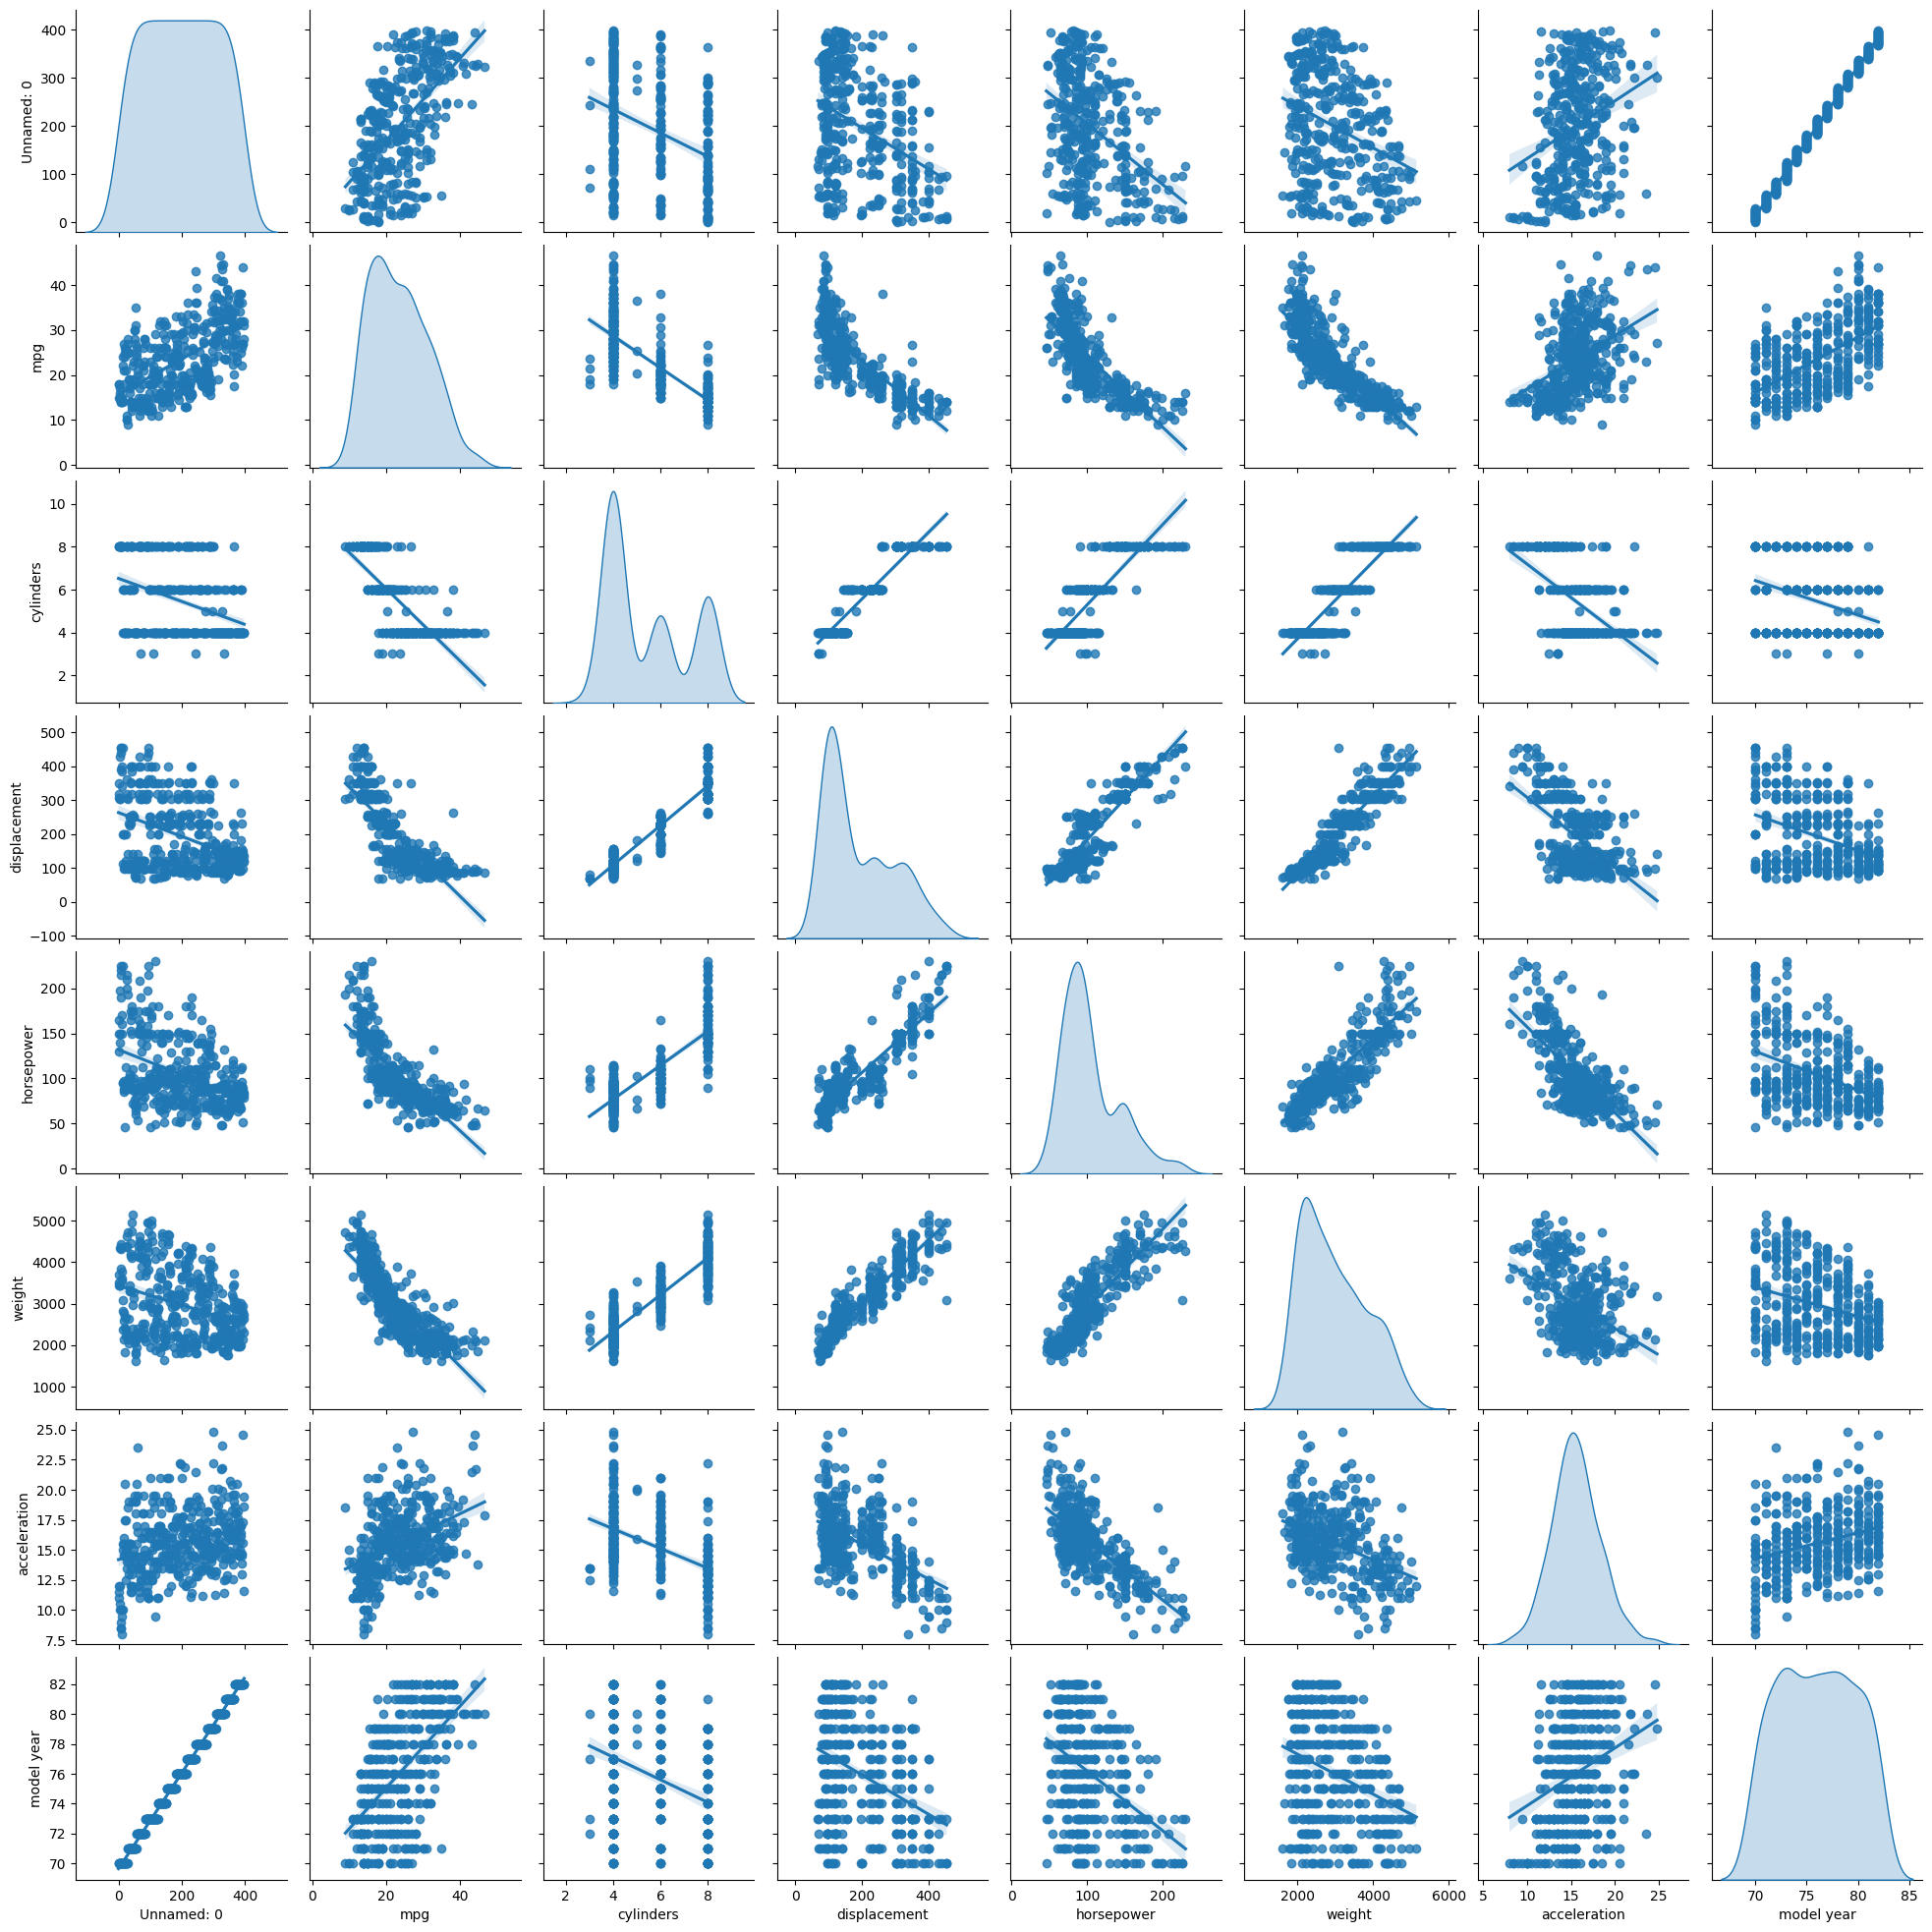

In [21]:
sns.pairplot(diag_kind="kde", kind="reg", data=mpg)

<Axes: xlabel='horsepower', ylabel='acceleration'>

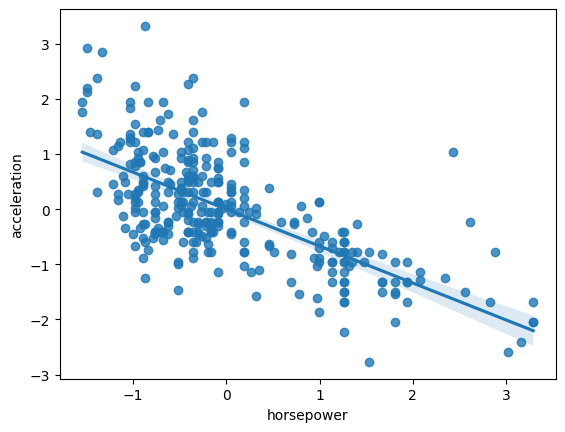

In [31]:
import numpy as np
sns.regplot(x=(X_train['horsepower']), y=X_train['acceleration'])

In [ ]:
glm = sm.GLM(y_train, X_train, family=sm.families.Gamma(link=sm.families.links.Log())).fit()
glm.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
               Results: Generalized linear model
===============================================================
Model:              GLM              AIC:            1537.3479 
Link Function:      Log              BIC:            -1770.3005
Dependent Variable: mpg              Log-Likelihood: -758.67   
Date:               2025-06-09 16:13 LL-Null:        -1881.0   
No. Observations:   318              Deviance:       4.4114    
Df Model:           9                Pearson chi2:   4.39      
Df Residuals:       308              Scale:          0.014237  
Method:             IRLS                                       
---------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------
const           3.1832   0.0184 173.1792 0.0000  3.1471  3.2192
Unnamed: 0     -0.1008   0.0903  -1.1164 0.2642 -0.2778  0.0762
cylinders      -0.0276   0.0223  -1.2377 0.2158 -0.0712  0.0161
displacement    0.0621   0.0328   1.8954 0.0580 -0.0021  0.1264
horsepower     -0.0524   0.0202  -2.5935 0.0095 -0.0919 -0.0128
weight         -0.2260   0.0219 -10.3014 0.0000 -0.2690 -0.1830
acceleration   -0.0058   0.0107  -0.5479 0.5838 -0.0267  0.0150
model year      0.2175   0.0899   2.4188 0.0156  0.0413  0.3937
origin_Japan   -0.0237   0.0224  -1.0556 0.2912 -0.0677  0.0203
origin_USA     -0.1086   0.0231  -4.7000 0.0000 -0.1538 -0.0633
===============================================================

"""

In [ ]:
X_train.head()

,const,Unnamed: 0,cylinders,displacement,horsepower,weight,acceleration,model year,origin_Japan,origin_USA
3,1.0,-1.768407,1.527188,1.090196,1.265821,0.552826,-1.319334,-1.696667,0.0,1.0
18,1.0,-1.634637,-0.850515,-0.922996,-0.408635,-0.999667,-0.413182,-1.696667,1.0,0.0
376,1.0,1.558020,-0.850515,-0.981350,-0.948782,-1.124772,0.927922,1.638975,1.0,0.0
248,1.0,0.416512,-0.850515,-0.981350,-1.164840,-1.392854,0.275493,0.527094,1.0,0.0
177,1.0,-0.216669,-0.850515,-0.747936,-0.219583,-0.327675,-0.231952,-0.306816,0.0,0.0


In [ ]:
l1_glm = sm.GLM(y_train, X_train, family=sm.families.Gamma(link=sm.families.links.Log())).fit_regularized(method="elastic_net", 
                                                                                                          alpha = 0.1, 
                                                                                                          L1_wt = 1, 
                                                                                                          maxiter = 5000)
l2_glm = sm.GLM(y_train, X_train, family=sm.families.Gamma(link=sm.families.links.Log())).fit_regularized(method="elastic_net", alpha = 1, L1_wt = 0, maxiter = 500000)

l1_glm.params

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1492: UserWarning: GLM ridge optimization may have failed, |grad|=0.000388
  warnings.warn(msg)


const           3.026952
cylinders       0.000000
displacement   -0.057249
horsepower      0.000000
weight         -0.154833
acceleration    0.000000
model_year      0.000000
origin_Japan    0.000000
origin_USA      0.000000
dtype: float64

In [ ]:
data = pd.concat([X_train, y_train], axis=1)

In [ ]:
print(smf.glm(formula="mpg ~ displacement + model_year", data=pd.concat([X_train, y_train], axis=1)).fit().summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    mpg   No. Observations:                  318
Model:                            GLM   Df Residuals:                      315
Model Family:                Gaussian   Df Model:                            2
Link Function:               Identity   Scale:                          16.866
Method:                          IRLS   Log-Likelihood:                -898.94
Date:                Mon, 09 Jun 2025   Deviance:                       5312.9
Time:                        16:48:43   Pearson chi2:                 5.31e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9346
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       23.6082      0.230    102.510   

In [ ]:
import select


sns.heatmap(X_train.loc[:, 'weight'])

IndexError: Inconsistent shape between the condition and the input (got (318, 1) and (318,))

MPG dataset loaded successfully.

Generating LOESS plots for the following numerical features against 'mpg':
- cylinders
- displacement
- horsepower
- weight
- acceleration
- model_year


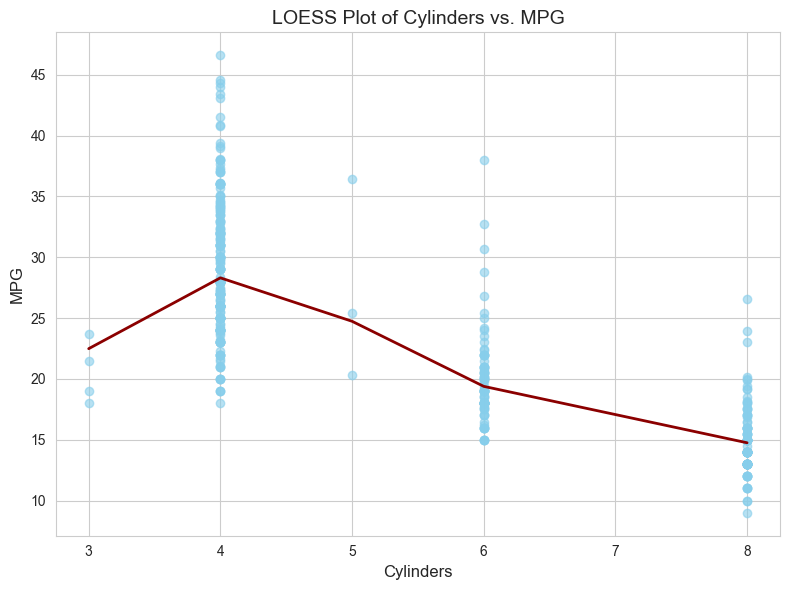

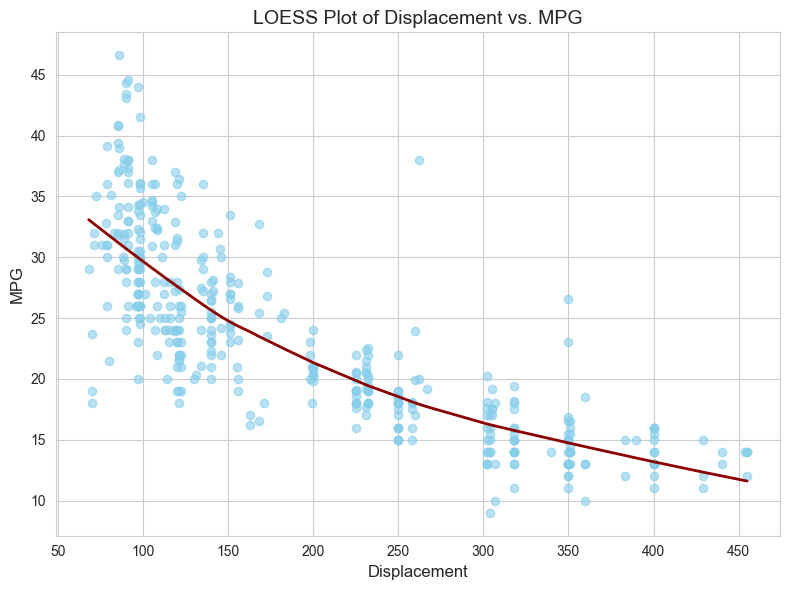

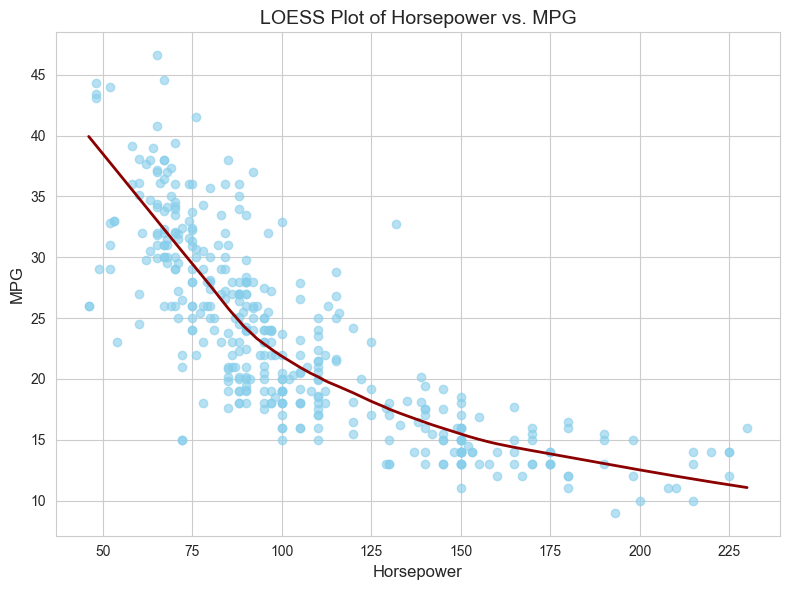

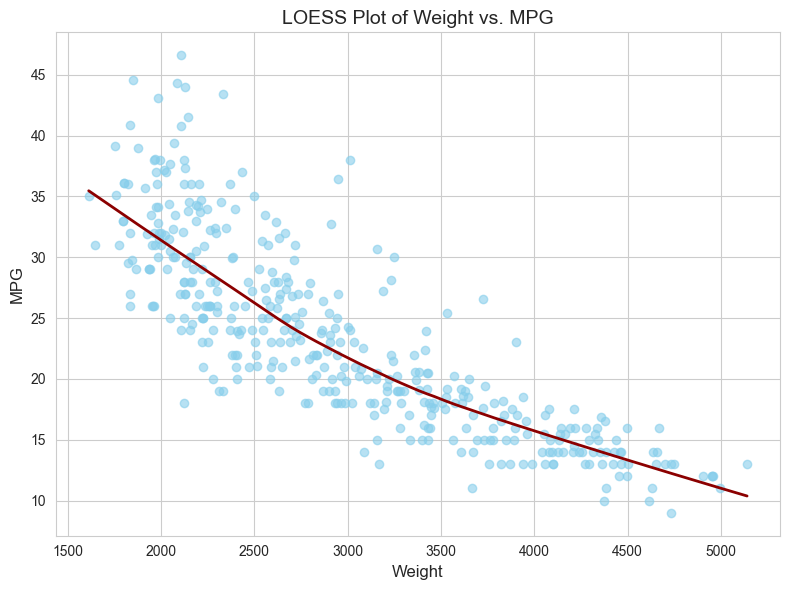

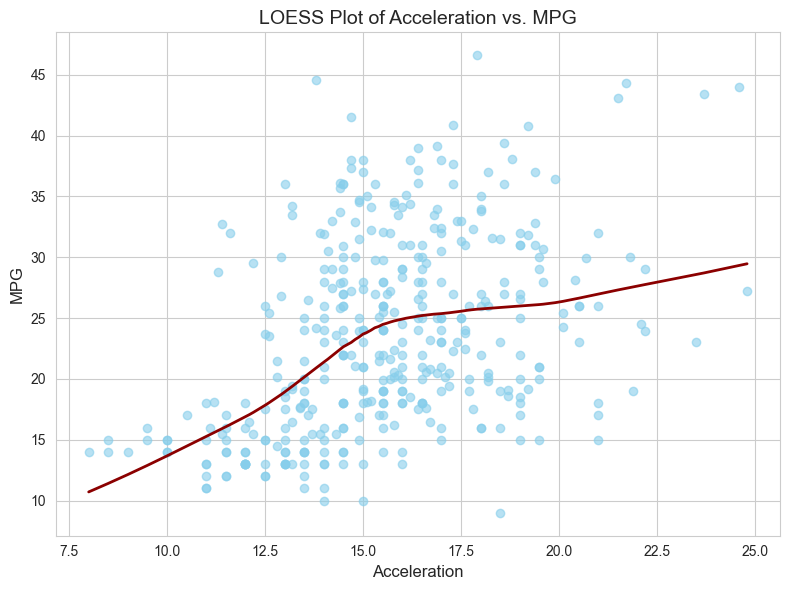

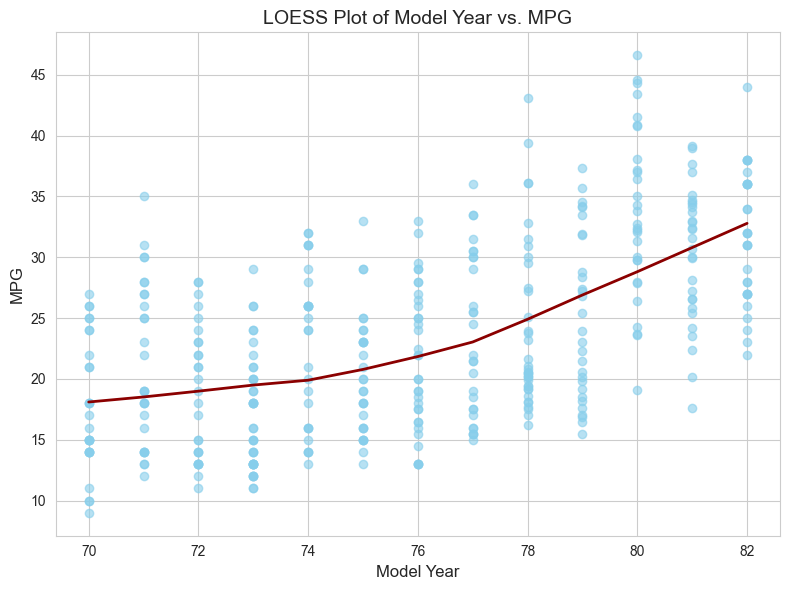


All LOESS plots have been generated.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the mpg dataset
# This dataset is commonly used for demonstrating regression analysis
try:
    mpg_df = sns.load_dataset('mpg')
    print("MPG dataset loaded successfully.")
except Exception as e:
    print(f"Error loading mpg dataset: {e}")
    print("Attempting to load from a common URL if seaborn's load_dataset fails.")
    # Fallback if seaborn's load_dataset fails (e.g., no internet, or dataset not available)
    try:
        mpg_df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv')
        print("MPG dataset loaded from URL.")
    except Exception as e_fallback:
        print(f"Failed to load mpg dataset from URL: {e_fallback}")
        print("Please ensure you have an active internet connection or the dataset is available locally.")
        exit() # Exit if dataset cannot be loaded

# Identify numerical columns for plotting
# We will iterate through these columns and plot them against 'mpg'
numerical_cols = mpg_df.select_dtypes(include=['number']).columns.tolist()

# Define the target variable for the y-axis
target_variable = 'mpg'

# Check if the target variable exists in the dataframe
if target_variable not in numerical_cols:
    print(f"Warning: '{target_variable}' not found in numerical columns. Cannot generate LOESS plots against it.")
    exit()

# Filter out the target variable itself from the x-axis list
# We don't want to plot 'mpg' against 'mpg' in this context
features_to_plot = [col for col in numerical_cols if col != target_variable]

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6) # Set default figure size

print(f"\nGenerating LOESS plots for the following numerical features against '{target_variable}':")
for feature in features_to_plot:
    print(f"- {feature}")

# Generate LOESS plots for each numerical feature against 'mpg'
for feature in features_to_plot:
    plt.figure() # Create a new figure for each plot

    # Create the regplot with lowess=True for LOESS smoothing
    # x: The numerical feature
    # y: The target variable 'mpg'
    # data: The DataFrame
    # scatter_kws: Keyword arguments for the scatter plot (e.g., transparency)
    # line_kws: Keyword arguments for the LOESS line (e.g., color)
    sns.regplot(
        x=feature,
        y=target_variable,
        data=mpg_df,
        lowess=True, # This enables the LOESS smoothing
        scatter_kws={'alpha': 0.6, 'color': 'skyblue'}, # Scatter plot points styling
        line_kws={'color': 'darkred', 'linewidth': 2} # LOESS line styling
    )

    # Add title and labels for clarity
    plt.title(f'LOESS Plot of {feature.replace("_", " ").title()} vs. {target_variable.upper()}', fontsize=14)
    plt.xlabel(f'{feature.replace("_", " ").title()}', fontsize=12)
    plt.ylabel(f'{target_variable.upper()}', fontsize=12)

    # Add a tight layout to prevent labels from overlapping
    plt.tight_layout()

    # Display the plot
    plt.show()

print("\nAll LOESS plots have been generated.")


# GAM with smooth effect of acceleration

In [ ]:

from statsmodels.gam.api import BSplines, CyclicCubicSplines

bs_spline = BSplines(mpg_df['acceleration'], 6, 3)

gam = sm.GLMGam.from_formula("mpg ~ weight + cylinders ", data=mpg_df, smoother = bs_spline)

gam.fit()
optimal_alpha = gam.select_penweight()[0]

gam_optimal = sm.GLMGam.from_formula("mpg ~ weight + cylinders ", data=mpg_df, smoother = bs_spline, alpha=optimal_alpha)
res_optimal = gam_optimal.fit()

res_optimal.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: GLMGam
================================================================
Model:                GLMGam           AIC:            2289.7989
Link Function:        Identity         BIC:            4793.8454
Dependent Variable:   mpg              Log-Likelihood: -1139.3  
Date:                 2025-06-10 21:18 LL-Null:        -1609.4  
No. Observations:     398              Deviance:       7143.2   
Df Model:             4                Pearson chi2:   7.14e+03 
Df Residuals:         392              Scale:          18.202   
Method:               IRLS                                      
----------------------------------------------------------------
                 Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
----------------------------------------------------------------
Intercept       45.5858   1.9950  22.8502 0.0000 41.6757 49.4959
weight          -0.0066   0.0006 -11.4566 0.0000 -0.0077 -0.0054
cylinders       -0.5576   0.3033  -1.8385 0.0660 -1.1521  0.0368
acceleration_s0  0.2767   1.2288   0.2252 0.8219 -2.1318  2.6851
acceleration_s1  0.2044   1.7188   0.1189 0.9053 -3.1643  3.5731
acceleration_s2  0.0880   1.7066   0.0516 0.9589 -3.2569  3.4329
acceleration_s3  2.6228   1.9080   1.3747 0.1692 -1.1167  6.3624
acceleration_s4  5.4782   2.3060   2.3757 0.0175  0.9586  9.9978
================================================================

"""

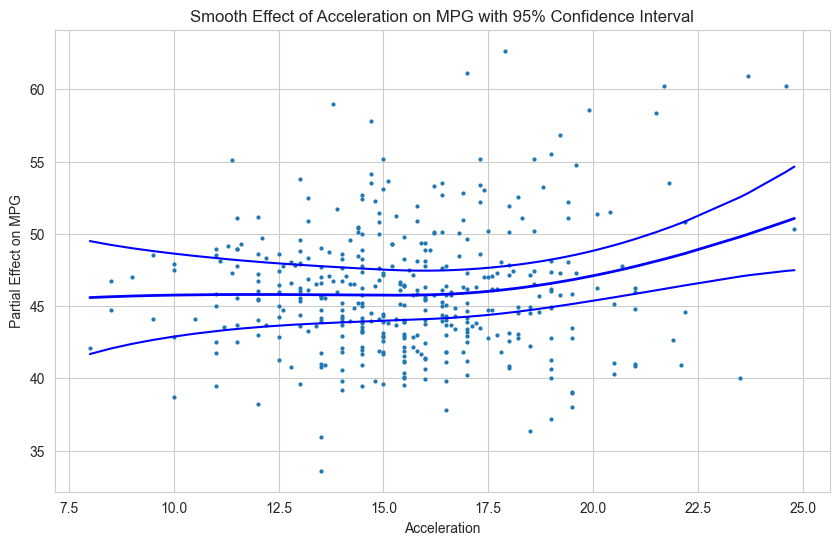

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
res_optimal.plot_partial(
    0,                # Index of the smooth term (0 for acceleration)
    ax=ax,
    cpr=True          # Show component-plus-residual points
)
ax.set_title('Smooth Effect of Acceleration on MPG with 95% Confidence Interval')
ax.set_xlabel('Acceleration')
ax.set_ylabel('Partial Effect on MPG')
plt.grid(True)
plt.show()


# GAM with smooth effect of cylinders

In [ ]:

from statsmodels.gam.api import BSplines, CyclicCubicSplines

bs_spline = BSplines(mpg_df['cylinders'], 6, 3)

gam = sm.GLMGam.from_formula("mpg ~ weight ", data=mpg_df, smoother = bs_spline)

gam.fit()
optimal_alpha = gam.select_penweight()[0]

gam_optimal = sm.GLMGam.from_formula("mpg ~ weight ", data=mpg_df, smoother = bs_spline, alpha=optimal_alpha)
res_optimal = gam_optimal.fit()

res_optimal.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Results: GLMGam
==============================================================
Model:              GLMGam           AIC:            2264.5295
Link Function:      Identity         BIC:            4359.8318
Dependent Variable: mpg              Log-Likelihood: -1126.9  
Date:               2025-06-10 21:23 LL-Null:        -1640.1  
No. Observations:   398              Deviance:       6710.3   
Df Model:           4                Pearson chi2:   6.71e+03 
Df Residuals:       392              Scale:          17.090   
Method:             IRLS                                      
--------------------------------------------------------------
              Coef.  Std.Err.    z     P>|z|   [0.025   0.975]
--------------------------------------------------------------
Intercept    35.1239   2.4234  14.4938 0.0000  30.3741 39.8736
weight       -0.0062   0.0006 -11.0421 0.0000  -0.0072 -0.0051
cylinders_s0  1.5839   3.8165   0.4150 0.6781  -5.8963  9.0642
cylinders_s1 15.2657   4.7798   3.1938 0.0014   5.8974 24.6340
cylinders_s2  3.2530   5.5359   0.5876 0.5568  -7.5973 14.1032
cylinders_s3 -1.0343  10.5117  -0.0984 0.9216 -21.6369 19.5683
cylinders_s4  5.1566   2.2993   2.2427 0.0249   0.6500  9.6632
==============================================================

"""

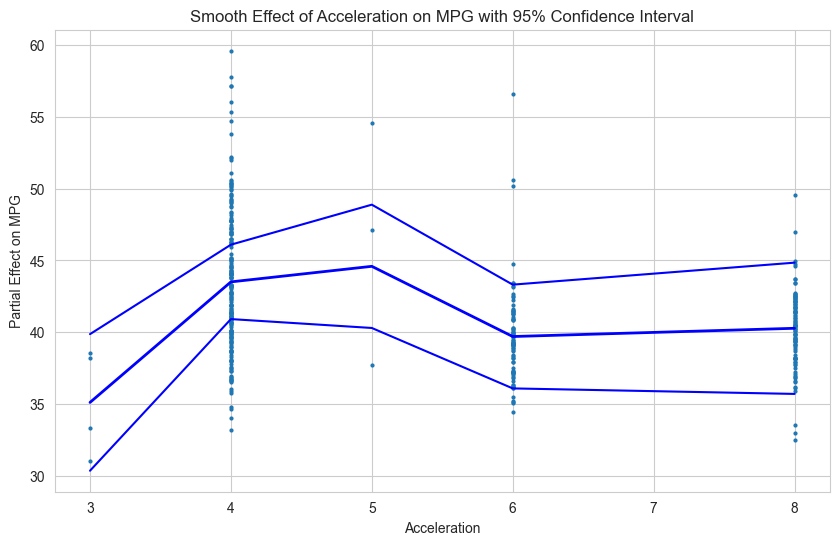

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
res_optimal.plot_partial(
    0,                # Index of the smooth term (0 for acceleration)
    ax=ax,
    cpr=True          # Show component-plus-residual points
)
ax.set_title('Smooth Effect of Acceleration on MPG with 95% Confidence Interval')
ax.set_xlabel('Acceleration')
ax.set_ylabel('Partial Effect on MPG')
plt.grid(True)
plt.show()
